Train data shape: (13903, 17)
Test data shape: (3476, 17)
Mean Squared Error on test set: 23553.842904647856
R^2 on test set: 0.25616494747598406


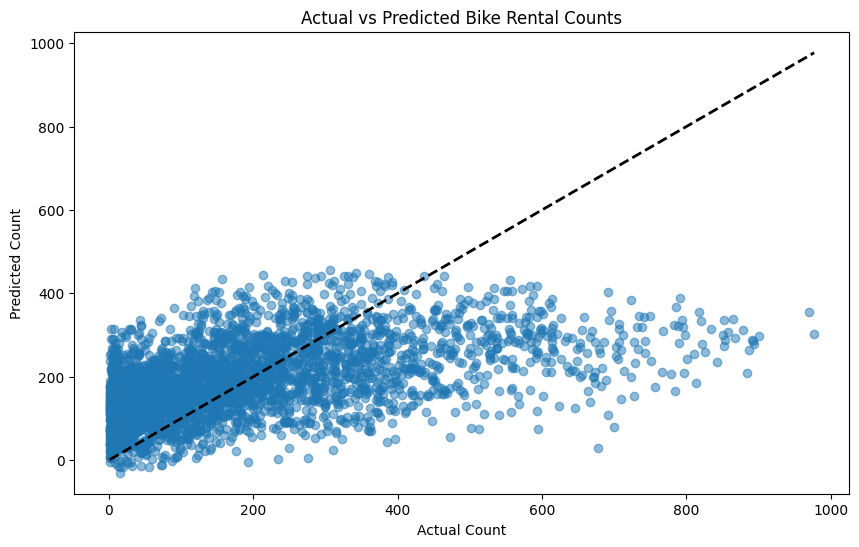

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Load the dataset
hourly_bike = pd.read_csv('../data/hour.csv')

# standardize the data
scaler = StandardScaler()
hourly_bike[['temp', 'hum', 'windspeed']] = scaler.fit_transform(hourly_bike[['temp', 'hum', 'windspeed']])

# train/test split
train_data, test_data = train_test_split(hourly_bike, test_size=0.2, random_state=42)
print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# Fit a simple linear regression model
model = LinearRegression(fit_intercept=True)
X_train = train_data[['temp', 'hum', 'windspeed']]
y_train = train_data['cnt']
model.fit(X_train, y_train)

# Evaluate the model
X_test = test_data[['temp', 'hum', 'windspeed']]
y_test = test_data['cnt']
y_pred = model.predict(X_test)
mse = ((y_test - y_pred) ** 2).mean()
print(f"Mean Squared Error on test set: {mse}")

# calculate R^2
r2 = model.score(X_test, y_test)
print(f"R^2 on test set: {r2}")

# Plot actual vs predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Actual vs Predicted Bike Rental Counts')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.show()

=== Model with Sinusoidal Features ===
Mean Squared Error: 17951.74
Root Mean Squared Error: 133.98
Mean Absolute Error: 94.01
R² Score: 0.4331

=== Baseline Model (No Temporal Features) ===
R² Score: 0.2562
Improvement: 0.1769


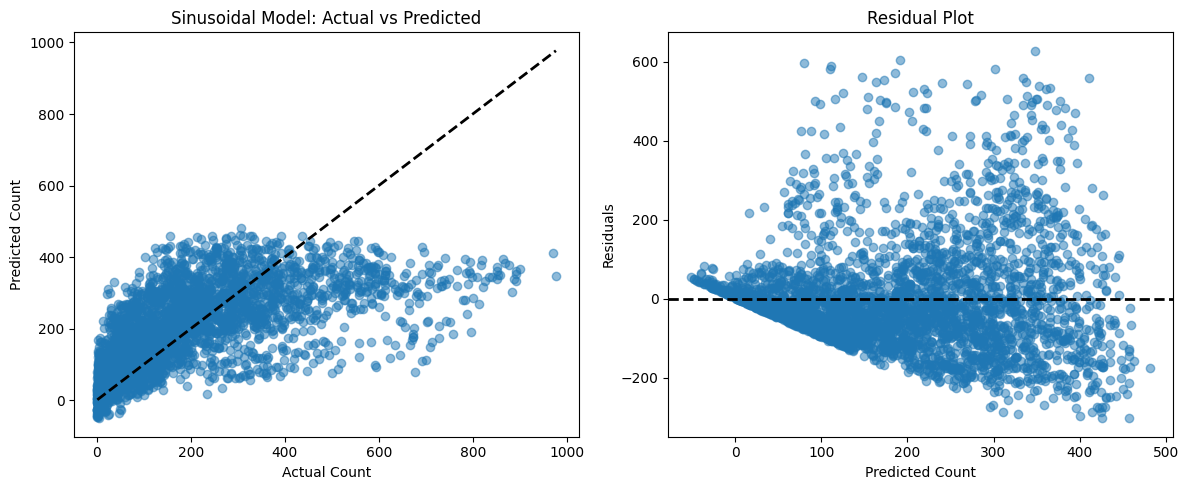

In [22]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# Create sinusoidal features for time of day and month
train_data_copy = train_data.copy()
test_data_copy = test_data.copy()

# Convert dteday to datetime if not already
train_data_copy['dteday'] = pd.to_datetime(train_data_copy['dteday'])
test_data_copy['dteday'] = pd.to_datetime(test_data_copy['dteday'])

# Create sinusoidal features for hour of day (0-23)
train_data_copy['hour_sin'] = np.sin(2 * np.pi * train_data_copy['hr'] / 24)
train_data_copy['hour_cos'] = np.cos(2 * np.pi * train_data_copy['hr'] / 24)
test_data_copy['hour_sin'] = np.sin(2 * np.pi * test_data_copy['hr'] / 24)
test_data_copy['hour_cos'] = np.cos(2 * np.pi * test_data_copy['hr'] / 24)

# Create sinusoidal features for month (1-12), offset by 1
train_data_copy['month_sin'] = np.sin(2 * np.pi * (train_data_copy['mnth'] - 1) / 12)
train_data_copy['month_cos'] = np.cos(2 * np.pi * (train_data_copy['mnth'] - 1) / 12)
test_data_copy['month_sin'] = np.sin(2 * np.pi * (test_data_copy['mnth'] - 1) / 12)
test_data_copy['month_cos'] = np.cos(2 * np.pi * (test_data_copy['mnth'] - 1) / 12)

# Fit linear regression model with sinusoidal features
model_sinusoidal = LinearRegression()
X_train_sin = train_data_copy[['temp', 'hum', 'windspeed', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
y_train_sin = train_data_copy['cnt']
model_sinusoidal.fit(X_train_sin, y_train_sin)

# Evaluate on test set
X_test_sin = test_data_copy[['temp', 'hum', 'windspeed', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']]
y_test_sin = test_data_copy['cnt']
y_pred_sin = model_sinusoidal.predict(X_test_sin)

# Calculate metrics
mse_sin = ((y_test_sin - y_pred_sin) ** 2).mean()
rmse_sin = np.sqrt(mse_sin)
mae_sin = mean_absolute_error(y_test_sin, y_pred_sin)
r2_sin = r2_score(y_test_sin, y_pred_sin)

print("=== Model with Sinusoidal Features ===")
print(f"Mean Squared Error: {mse_sin:.2f}")
print(f"Root Mean Squared Error: {rmse_sin:.2f}")
print(f"Mean Absolute Error: {mae_sin:.2f}")
print(f"R² Score: {r2_sin:.4f}")

# Compare with baseline model
r2_baseline = r2_score(y_test, y_pred)
print(f"\n=== Baseline Model (No Temporal Features) ===")
print(f"R² Score: {r2_baseline:.4f}")
print(f"Improvement: {(r2_sin - r2_baseline):.4f}")

# Plot comparison
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(y_test_sin, y_pred_sin, alpha=0.5, label='With Sinusoidal Features')
plt.xlabel('Actual Count')
plt.ylabel('Predicted Count')
plt.title('Sinusoidal Model: Actual vs Predicted')
plt.plot([y_test_sin.min(), y_test_sin.max()], [y_test_sin.min(), y_test_sin.max()], 'k--', lw=2)

plt.subplot(1, 2, 2)
residuals = y_test_sin - y_pred_sin
plt.scatter(y_pred_sin, residuals, alpha=0.5)
plt.axhline(y=0, color='k', linestyle='--', lw=2)
plt.xlabel('Predicted Count')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.tight_layout()
plt.show()